In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vinayak121/steels-data-set/tensile-properties-from-jeffs-ml-sheet-20220208.csv
/kaggle/input/datasets/vinayak121/steels-data-set/hr_alloys20220208/HR52-B/16.bmp
/kaggle/input/datasets/vinayak121/steels-data-set/hr_alloys20220208/HR52-B/4.bmp
/kaggle/input/datasets/vinayak121/steels-data-set/hr_alloys20220208/HR52-B/23.bmp
/kaggle/input/datasets/vinayak121/steels-data-set/hr_alloys20220208/HR52-B/12.bmp
/kaggle/input/datasets/vinayak121/steels-data-set/hr_alloys20220208/HR52-B/37.bmp
/kaggle/input/datasets/vinayak121/steels-data-set/hr_alloys20220208/HR52-B/28.bmp
/kaggle/input/datasets/vinayak121/steels-data-set/hr_alloys20220208/HR52-B/1.bmp
/kaggle/input/datasets/vinayak121/steels-data-set/hr_alloys20220208/HR52-B/29.bmp
/kaggle/input/datasets/vinayak121/steels-data-set/hr_alloys20220208/HR52-B/18.bmp
/kaggle/input/datasets/vinayak121/steels-data-set/hr_alloys20220208/HR52-B/2.bmp
/kaggle/input/datasets/vinayak121/steels-data-set/hr_alloys20220208/HR52-B/6.bmp


# Assignment 8 — CNN Capstone Project

## Steel Microstructure Image Classification Using Convolutional Neural Network (CNN)

**Course:** Artificial Intelligence (Machine Learning & Deep Learning)  
**Program:** NAVTTC — Prime Minister's Hunarmand Pakistan Program  
**Project Type:** Image Classification using CNN  
**Dataset:** Steels Data Set  
**Classes:** CPJ, HR, P92  

### Objective

The objective of this project is to develop a Convolutional Neural Network (CNN) based image classification system that can classify steel microstructure images into three material groups: CPJ, HR, and P92.

The project includes dataset exploration, image preprocessing, data augmentation, CNN model development, model training, performance evaluation, and preparation of the trained model for deployment through a Streamlit web application.

## 1. Project Overview

This project applies deep learning and computer vision techniques to steel microstructure images.

Microstructure images contain visual information about the structure and appearance of steel materials. A CNN can automatically learn important visual features from these images and use those features for classification.

In this project, the images are classified into three main groups:

1. CPJ
2. HR
3. P92

The complete workflow is:

**Dataset → Exploration → Preprocessing → Data Augmentation → CNN → Training → Evaluation → Model Saving → Streamlit Application → Deployment**

## 2. Problem Statement

Manual analysis and classification of material microstructure images can require significant domain knowledge and time.

The goal of this project is to develop an automated image classification system using a Convolutional Neural Network (CNN). The system receives a steel microstructure image as input and predicts whether the image belongs to the CPJ, HR, or P92 group.

This project demonstrates how deep learning can be applied to image-based material characterization.

## 3. Project Objectives

The main objectives of this project are:

- To obtain and inspect a steel microstructure image dataset.
- To understand the structure and distribution of the dataset.
- To visualize representative microstructure images.
- To resize images into a common input size.
- To normalize image pixel values.
- To apply image augmentation to improve model generalization.
- To divide the available images into training and validation sets.
- To design and train a CNN model.
- To evaluate the CNN using accuracy and loss.
- To generate a confusion matrix.
- To calculate precision, recall, and F1-score.
- To save the trained CNN model.
- To prepare the model for a Streamlit web application.
- To deploy the application publicly through Streamlit Community Cloud.

## 4. Dataset Selection

### Dataset

The selected dataset is the **Steels Data Set** available on Kaggle.

### Dataset Source

Kaggle Steels Data Set:

https://www.kaggle.com/datasets/vinayak121/steels-data-set

### Dataset Structure

The dataset contains steel-related microstructure images organized into three main image groups:

- `cpj_alloys`
- `hr_alloys20220208`
- `p92_alloys`

The total number of available BMP images is **837**.

### Classification Classes

| Class | Description |
|---|---|
| CPJ | CPJ image group |
| HR | HR image group |
| P92 | P92 image group |

### Why This Dataset Was Selected

This dataset was selected because it provides real material microstructure images and therefore provides a meaningful image-classification problem suitable for a CNN.

The project is also relevant to materials characterization and demonstrates the application of artificial intelligence to scientific imaging.

## Import Libraries

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully.")
from sklearn.utils.class_weight import compute_class_weight

TensorFlow version: 2.20.0
Libraries imported successfully.


## Dataset Path

In [6]:
DATASET_PATH = "/kaggle/input/datasets/vinayak121/steels-data-set"

print("Dataset path:")
print(DATASET_PATH)

print("\nDataset contents:")
for item in os.listdir(DATASET_PATH):
    print(item)

Dataset path:
/kaggle/input/datasets/vinayak121/steels-data-set

Dataset contents:
tensile-properties-from-jeffs-ml-sheet-20220208.csv
hr_alloys20220208
cpj_alloys
p92_alloys


## Dataset Exploration

In [7]:
classes = {
    "CPJ": os.path.join(DATASET_PATH, "cpj_alloys"),
    "HR": os.path.join(DATASET_PATH, "hr_alloys20220208"),
    "P92": os.path.join(DATASET_PATH, "p92_alloys")
}

image_counts = {}

for class_name, class_path in classes.items():
    count = 0
    
    for root, dirs, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith(".bmp"):
                count += 1
    
    image_counts[class_name] = count

print("Image counts:")
for class_name, count in image_counts.items():
    print(f"{class_name}: {count}")

print("\nTotal images:", sum(image_counts.values()))

Image counts:
CPJ: 430
HR: 311
P92: 96

Total images: 837


## Class Distribution Visualization

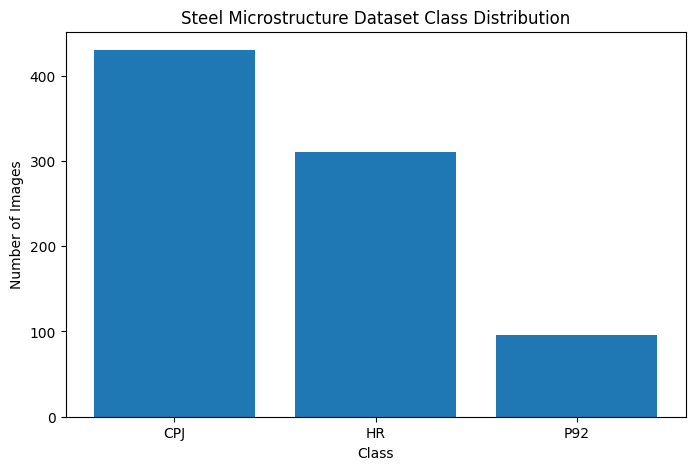

In [8]:
plt.figure(figsize=(8, 5))

plt.bar(
    image_counts.keys(),
    image_counts.values()
)

plt.title("Steel Microstructure Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

## Sample Images

CPJ
Path: /kaggle/input/datasets/vinayak121/steels-data-set/cpj_alloys/CPJ7J/16.bmp
Image size: (630, 592)
Mode: RGB

HR
Path: /kaggle/input/datasets/vinayak121/steels-data-set/hr_alloys20220208/HR52-B/16.bmp
Image size: (630, 592)
Mode: RGB

P92
Path: /kaggle/input/datasets/vinayak121/steels-data-set/p92_alloys/P92 OTHER/P92/16.bmp
Image size: (630, 592)
Mode: RGB



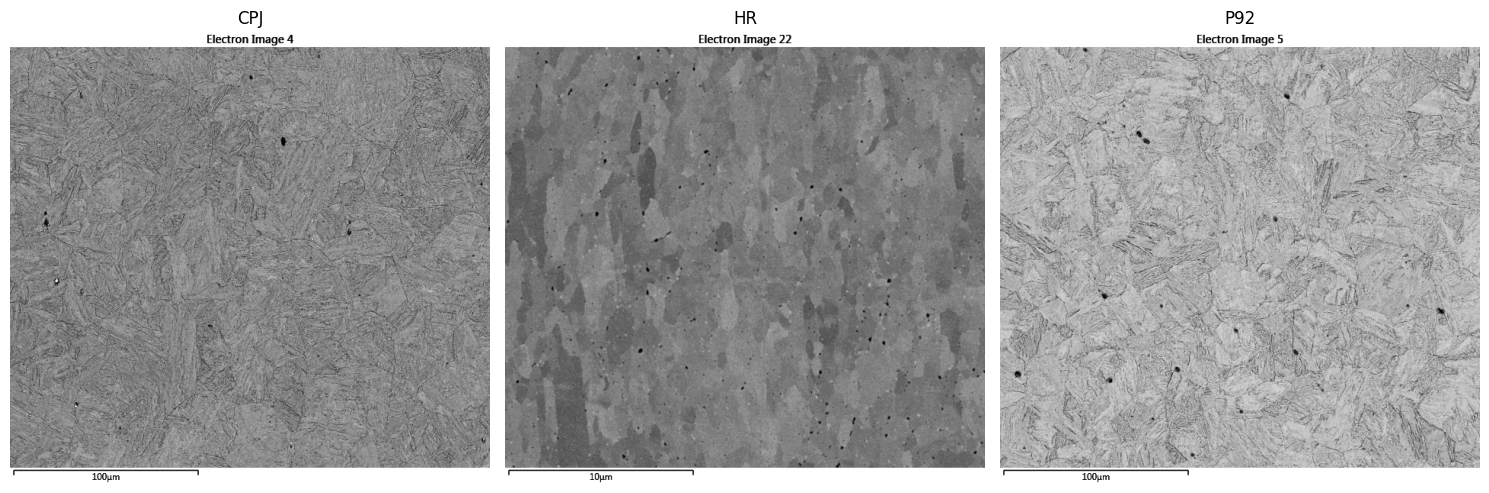

In [9]:
image_samples = []

for class_name, class_path in classes.items():
    found = False
    
    for root, dirs, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith(".bmp"):
                image_samples.append(
                    (class_name, os.path.join(root, file))
                )
                found = True
                break
        
        if found:
            break

plt.figure(figsize=(15, 5))

for i, (label, image_path) in enumerate(image_samples):

    img = Image.open(image_path)

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

    print(label)
    print("Path:", image_path)
    print("Image size:", img.size)
    print("Mode:", img.mode)
    print()

plt.tight_layout()
plt.show()

## 5. Image Preprocessing

Before training the CNN, the images are preprocessed.

The preprocessing steps are:

### 1. Resizing

The original images have a size of approximately 630 × 592 pixels. To provide a consistent input size to the CNN, all images are resized to:

**128 × 128 pixels**

### 2. Normalization

Image pixel values normally range from 0 to 255.

They are normalized to the range:

**0 to 1**

using:

`pixel / 255`

Normalization helps the neural network train more efficiently.

### 3. Data Augmentation

The training images are augmented using:

- Rotation
- Width shifting
- Height shifting
- Zoom
- Horizontal flipping

Data augmentation creates slightly modified versions of training images and can help the model generalize better.

## Preprocessing

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

In [11]:

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Training data: normalization + augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=0.20
)

# Validation data: normalization only
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    classes=["cpj_alloys", "hr_alloys20220208", "p92_alloys"],
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

validation_data = validation_datagen.flow_from_directory(
    DATASET_PATH,
    classes=["cpj_alloys", "hr_alloys20220208", "p92_alloys"],
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

print("Class mapping:")
print(train_data.class_indices)

print("\nTraining images:", train_data.samples)
print("Validation images:", validation_data.samples)

Found 670 images belonging to 3 classes.
Found 167 images belonging to 3 classes.
Class mapping:
{'cpj_alloys': 0, 'hr_alloys20220208': 1, 'p92_alloys': 2}

Training images: 670
Validation images: 167


In [12]:
classes = train_data.classes

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.6492248062015504), 1: np.float64(0.8969210174029452), 2: np.float64(2.9004329004329006)}


## Augmented Images

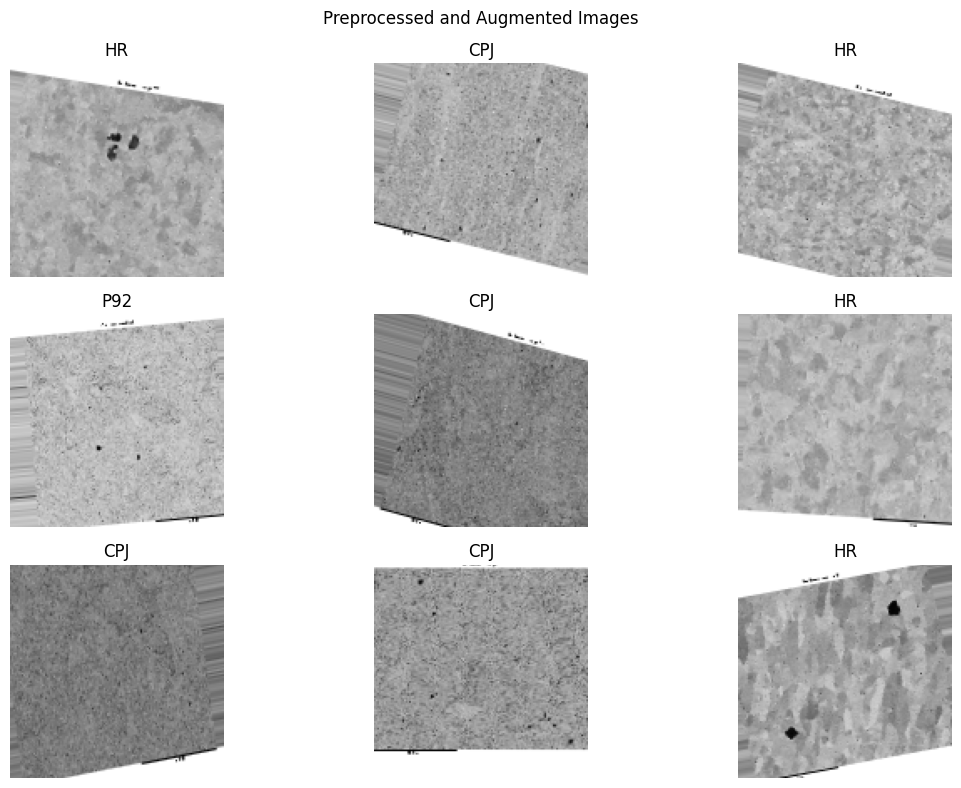

In [13]:
images, labels = next(train_data)

class_names = ["CPJ", "HR", "P92"]

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

plt.suptitle("Preprocessed and Augmented Images")
plt.tight_layout()
plt.show()

## 6. CNN Architecture

A Convolutional Neural Network (CNN) is used because the input data consists of images.

The proposed CNN contains:

1. Convolutional layer with 32 filters
2. Max Pooling layer
3. Convolutional layer with 64 filters
4. Max Pooling layer
5. Convolutional layer with 128 filters
6. Max Pooling layer
7. Flatten layer
8. Dense layer with 128 neurons
9. Dropout layer
10. Output layer with 3 neurons

The ReLU activation function is used in the convolutional and dense layers.

The final layer uses Softmax because this is a three-class classification problem.

## Build CNN

In [14]:
model = Sequential([
    
    Conv2D(
    32,
    (3, 3),
    activation="relu",
    input_shape=(*IMG_SIZE, 3)
),
    
    MaxPooling2D((2, 2)),
    
    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    
    MaxPooling2D((2, 2)),
    
    Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),
    
    MaxPooling2D((2, 2)),
    
    Flatten(),
    
    Dense(
        128,
        activation="relu"
    ),
    
    Dropout(0.5),
    
    Dense(
        3,
        activation="softmax"
    )
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-18 12:48:55.082694: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## Compile Model

In [15]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## 7. CNN Model Training

The CNN is trained using the training dataset and validated using the validation dataset.

### Training Configuration

- Optimizer: Adam
- Loss function: Categorical Cross-Entropy
- Evaluation metric: Accuracy
- Maximum epochs: 50
- Batch size: 32
- Early stopping: Enabled

Early stopping is used to reduce unnecessary training if the validation loss stops improving.

## Train Model

In [16]:
# -----------------------------------------
# Train CNN Model - 50 Epochs
# -----------------------------------------

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=30,
    callbacks=[early_stop]
    
)

print("CNN training completed.")

Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.4373 - loss: 1.0221 - val_accuracy: 0.5150 - val_loss: 0.9715
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 626ms/step - accuracy: 0.4687 - loss: 0.9816 - val_accuracy: 0.6647 - val_loss: 0.8857
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 636ms/step - accuracy: 0.5970 - loss: 0.8850 - val_accuracy: 0.6707 - val_loss: 0.8652
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 669ms/step - accuracy: 0.5866 - loss: 0.8961 - val_accuracy: 0.6587 - val_loss: 0.8821
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 22s 723ms/step - accuracy: 0.6134 - loss: 0.8477 - val_accuracy: 0.6287 - val_loss: 0.9106
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 669ms/step - accuracy: 0.6299 - loss: 0.8301 - val_accuracy: 0.6467 - val_loss: 1.0160
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 630ms/step - accuracy: 0.6657 - loss: 0.8052 - val_accuracy: 0.6467 - val_loss: 0.9597
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 635ms/step - accuracy: 0.6910 - loss: 0.7291 - val_accurac

## Training Performance

The CNN model was trained using the steel microstructure image dataset.

The training and validation accuracy and loss are plotted below to analyze the learning behavior of the model. These curves help us identify whether the model is learning effectively and whether overfitting is occurring.

## Plot training and validation accuracy/loss

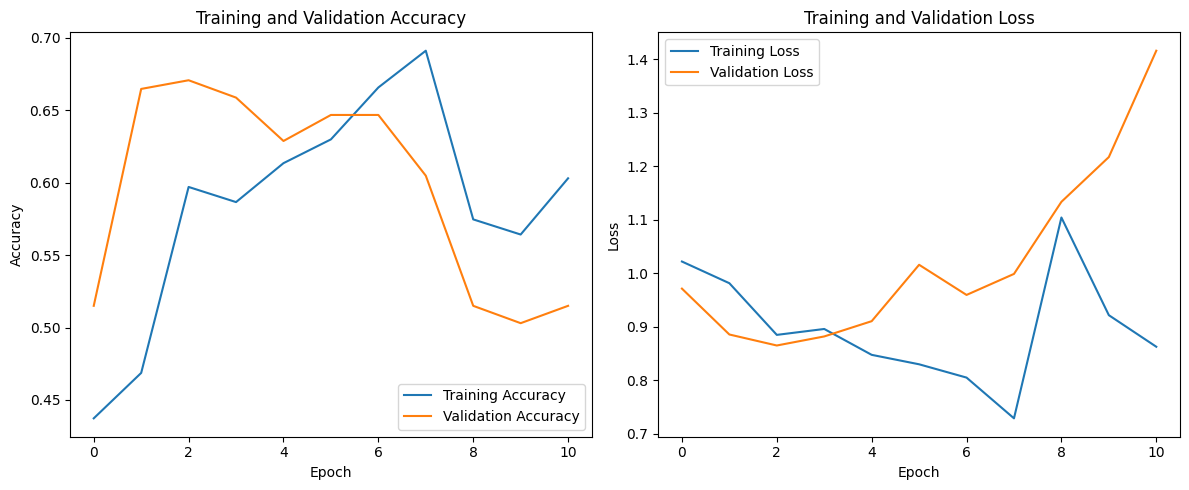

In [17]:


plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Model Evaluation

After training, the CNN model is evaluated on the validation dataset.

The validation accuracy and validation loss are used to measure the performance of the trained model on images that were not used for training.

# Evaluate the CNN model

In [18]:
val_loss, val_accuracy = model.evaluate(validation_data, verbose=1)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)
print("Validation Accuracy (%):", round(val_accuracy * 100, 2))

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.6707 - loss: 0.8652
Validation Loss: 0.86517733335495
Validation Accuracy: 0.6706587076187134
Validation Accuracy (%): 67.07


## Confusion Matrix

A confusion matrix is used to analyze the classification performance of the CNN model for each class.

It shows how many images were correctly classified and how many images were incorrectly classified into another class.

The three classes in this project are:

1. CPJ Alloys
2. HR Alloys
3. P92 Alloys

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step


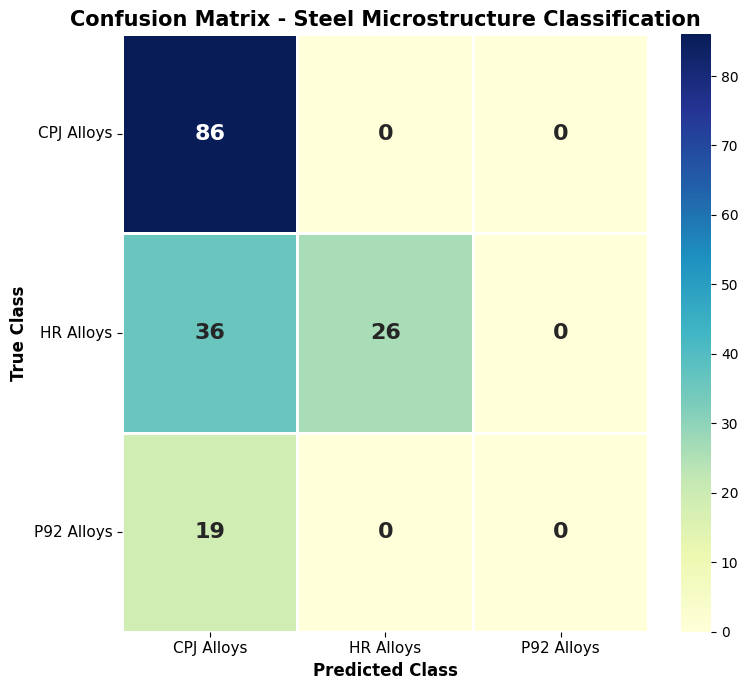

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Reset validation generator
validation_data.reset()

# Get predictions
predictions = model.predict(validation_data)

# Convert probabilities to predicted class numbers
y_pred = np.argmax(predictions, axis=1)

# Get true class labels
y_true = validation_data.classes

# Class names
class_names = list(validation_data.class_indices.keys())

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
plt.figure(figsize=(8, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",       # Bright and clear colors
    xticklabels=["CPJ Alloys", "HR Alloys", "P92 Alloys"],
    yticklabels=["CPJ Alloys", "HR Alloys", "P92 Alloys"],
    linewidths=1,
    linecolor="white",
    annot_kws={"size": 16, "weight": "bold"}
)

plt.title("Confusion Matrix - Steel Microstructure Classification",
          fontsize=15, fontweight="bold")
plt.xlabel("Predicted Class", fontsize=12, fontweight="bold")
plt.ylabel("True Class", fontsize=12, fontweight="bold")

plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

## Classification Report

The classification report provides detailed performance metrics for each class.

It includes precision, recall, and F1-score. These metrics help evaluate how well the CNN model distinguishes between CPJ Alloys, HR Alloys, and P92 Alloys.

In [20]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=["CPJ Alloys", "HR Alloys", "P92 Alloys"]
)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

  CPJ Alloys       0.61      1.00      0.76        86
   HR Alloys       1.00      0.42      0.59        62
  P92 Alloys       0.00      0.00      0.00        19

    accuracy                           0.67       167
   macro avg       0.54      0.47      0.45       167
weighted avg       0.69      0.67      0.61       167



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Save Trained Model

The trained CNN model is saved so that it can later be loaded into the
Streamlit web application for image classification.

In [21]:
model.save("/kaggle/working/steel_microstructure_cnn.keras")

print("Model saved successfully.")

Model saved successfully.


## Test Prediction on a Single Image

A sample image is passed to the trained model to demonstrate how the final
system performs classification on an individual microstructure image.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


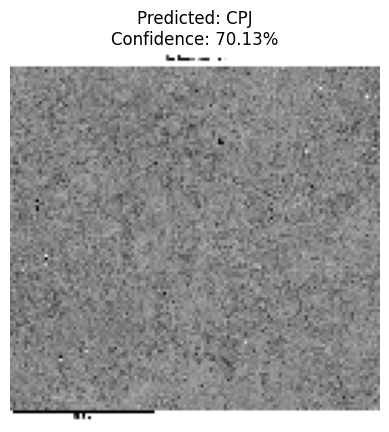

Predicted class: CPJ
Confidence: 70.13 %


In [22]:
from tensorflow.keras.utils import load_img, img_to_array

sample_path = image_samples[0][1]

img = load_img(sample_path, target_size=IMG_SIZE)
img_array = img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_index = np.argmax(prediction[0])

class_mapping = {
    0: "CPJ",
    1: "HR",
    2: "P92"
}

predicted_class = class_mapping[predicted_index]
confidence = np.max(prediction[0]) * 100

plt.imshow(img)
plt.axis("off")
plt.title(
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.show()

print("Predicted class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

In [23]:
print("Best Train Accuracy:",
      max(history.history['accuracy']))

print("Best Validation Accuracy:",
      max(history.history['val_accuracy']))

Best Train Accuracy: 0.6910447478294373
Best Validation Accuracy: 0.6706587076187134
